In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Relevant packages
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
import warnings
from sklearn.datasets import make_classification

# read dataset from drive into colab notebook

In [ ]:
# read the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/heart.csv")
df.head() #top 5 data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# check row by column

In [ ]:
df.shape

(918, 12)

In [ ]:
df.isna().sum()  # check for null values in every columns

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


# check the columns types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


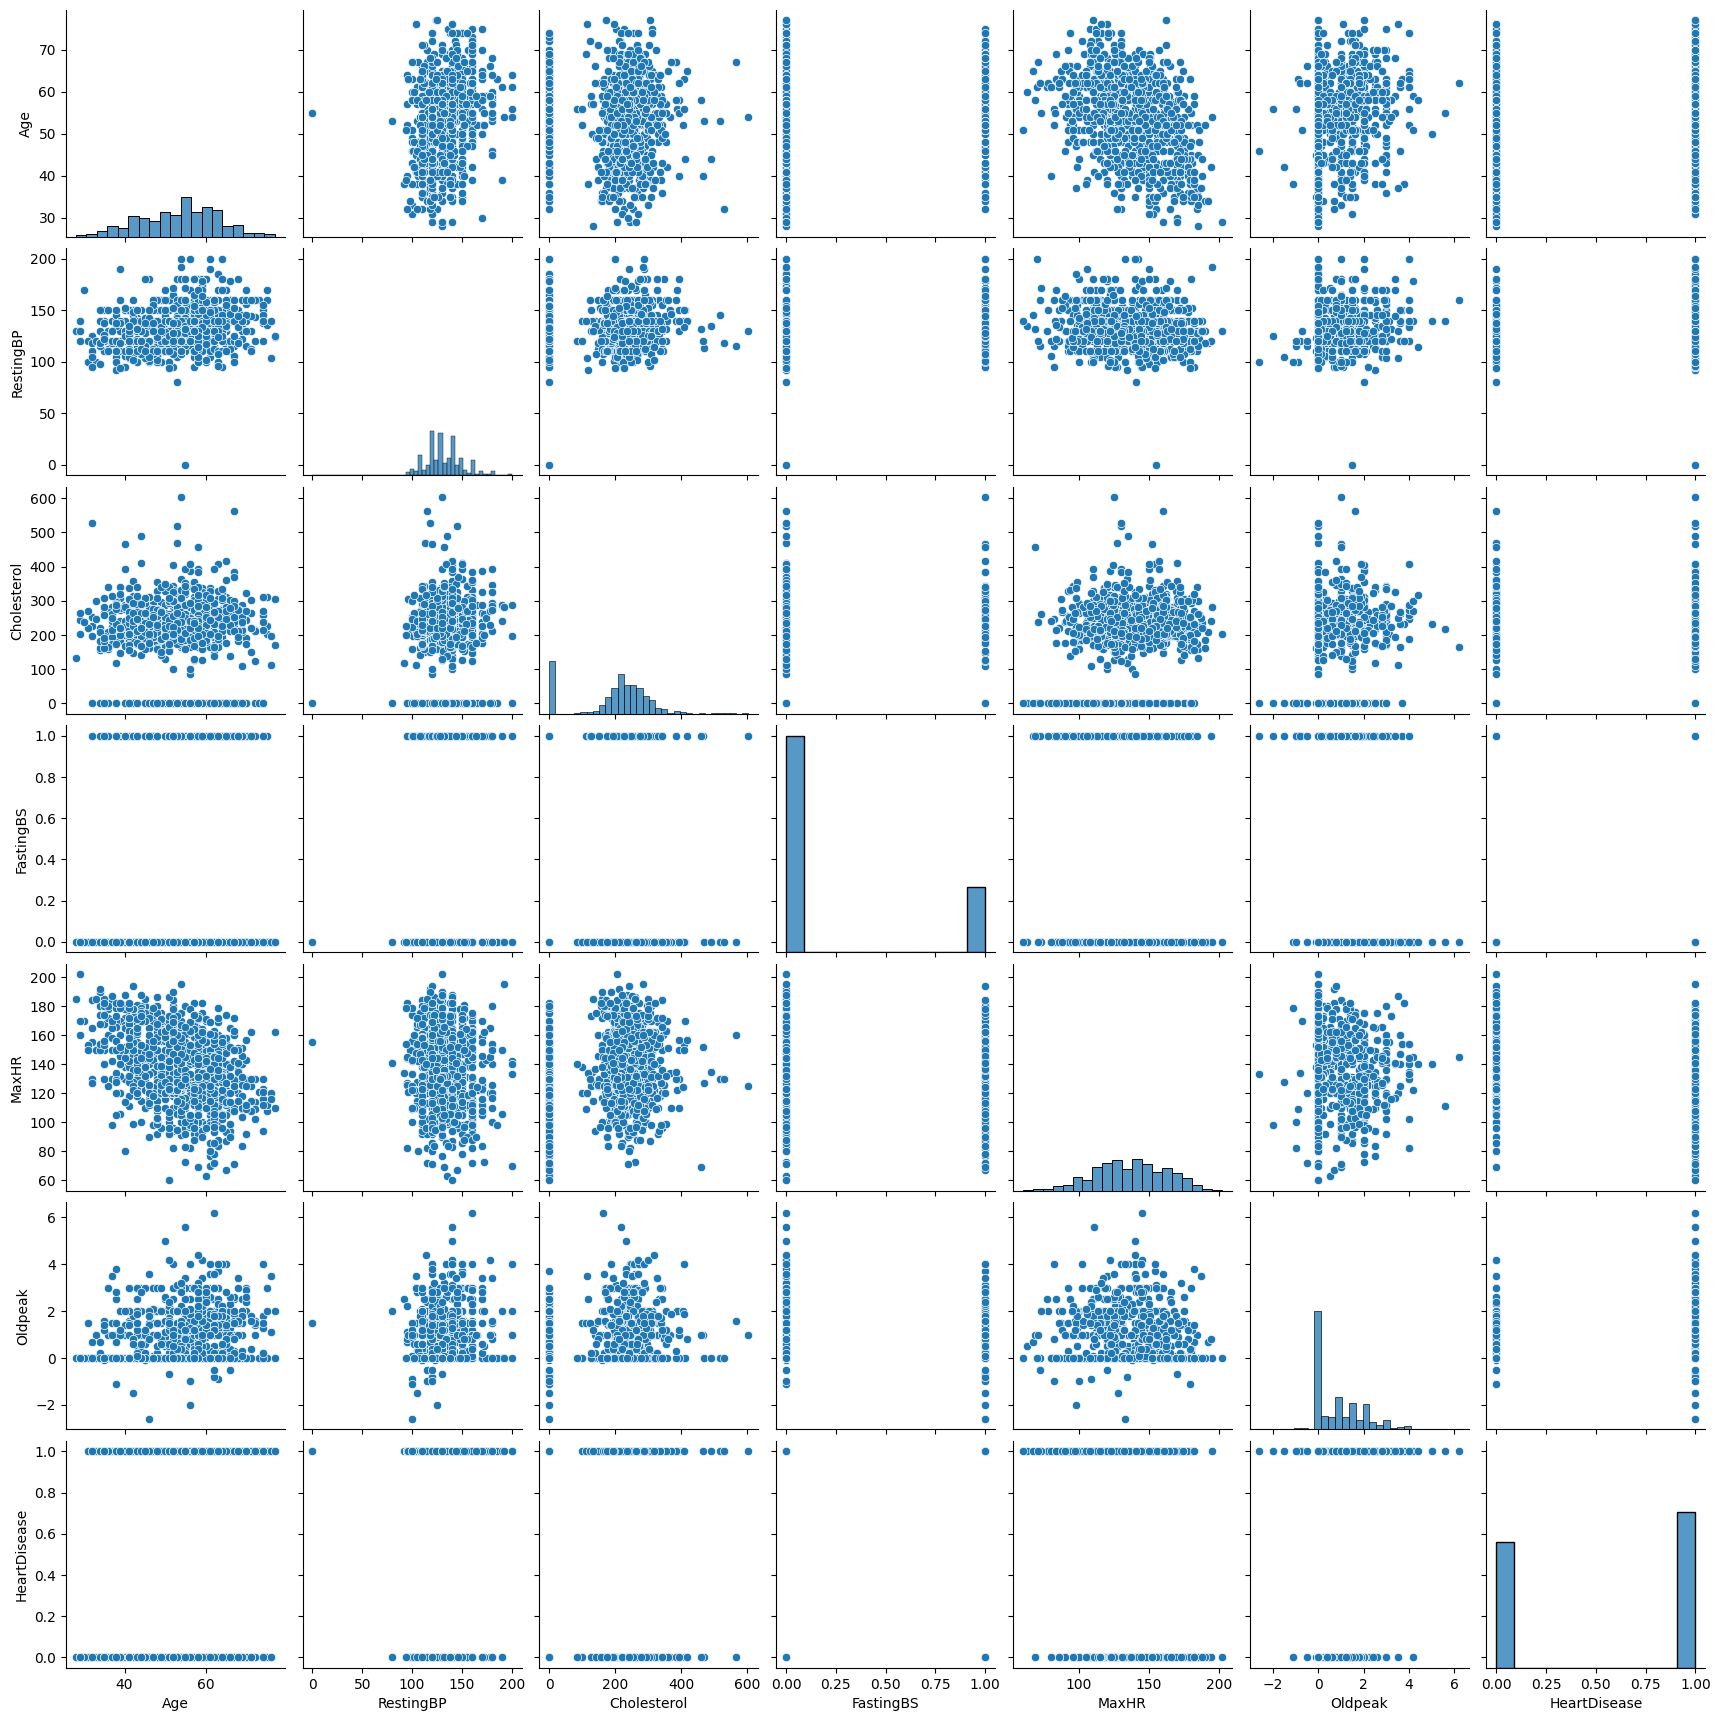

In [ ]:
sns.pairplot(df)

In [ ]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


In [ ]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


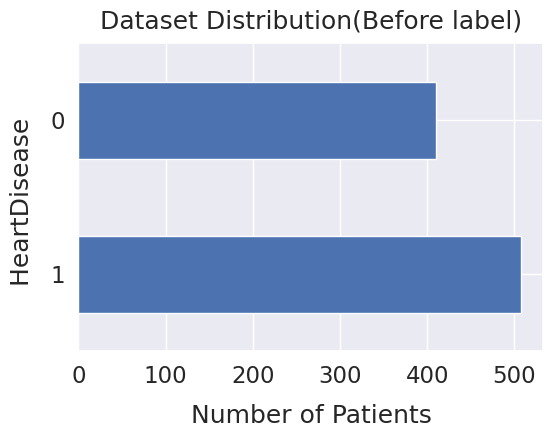

In [ ]:
sns.set(font_scale=1.5)
df['HeartDisease'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Number of Patients", labelpad=12)
plt.ylabel("HeartDisease ", labelpad=12)
plt.yticks()
plt.title("Dataset Distribution(Before label)", y=1.02);
# Save the plot as a file
plt.savefig('Dataset distribution.png', bbox_inches='tight', dpi = 300, facecolor='white', transparent=False)

# Show the plot
plt.show()

In [ ]:
df["ChestPainType"].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


In [ ]:
df["RestingECG"].value_counts()

,count
RestingECG,
Normal,552
LVH,188
ST,178


In [ ]:
df["ExerciseAngina"].value_counts()

,count
ExerciseAngina,
N,547
Y,371


In [ ]:
df["ST_Slope"].value_counts()

,count
ST_Slope,
Flat,460
Up,395
Down,63


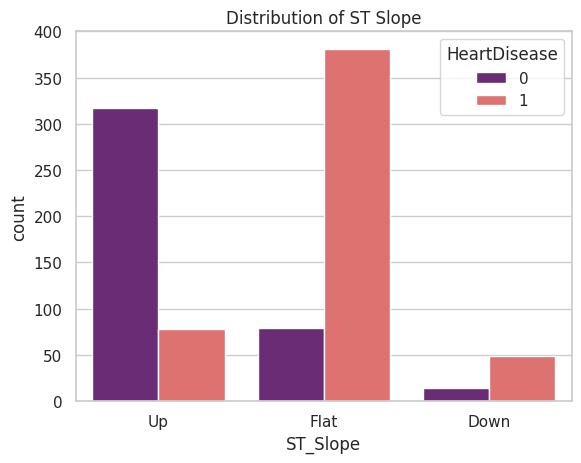

In [ ]:
sns.countplot(data=df, x='ST_Slope', palette='magma', hue = 'HeartDisease')
plt.title('Distribution of ST Slope')
plt.show()

**Make a copy**

In [ ]:
df1=df.copy()

In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

# Visulized the feature labels

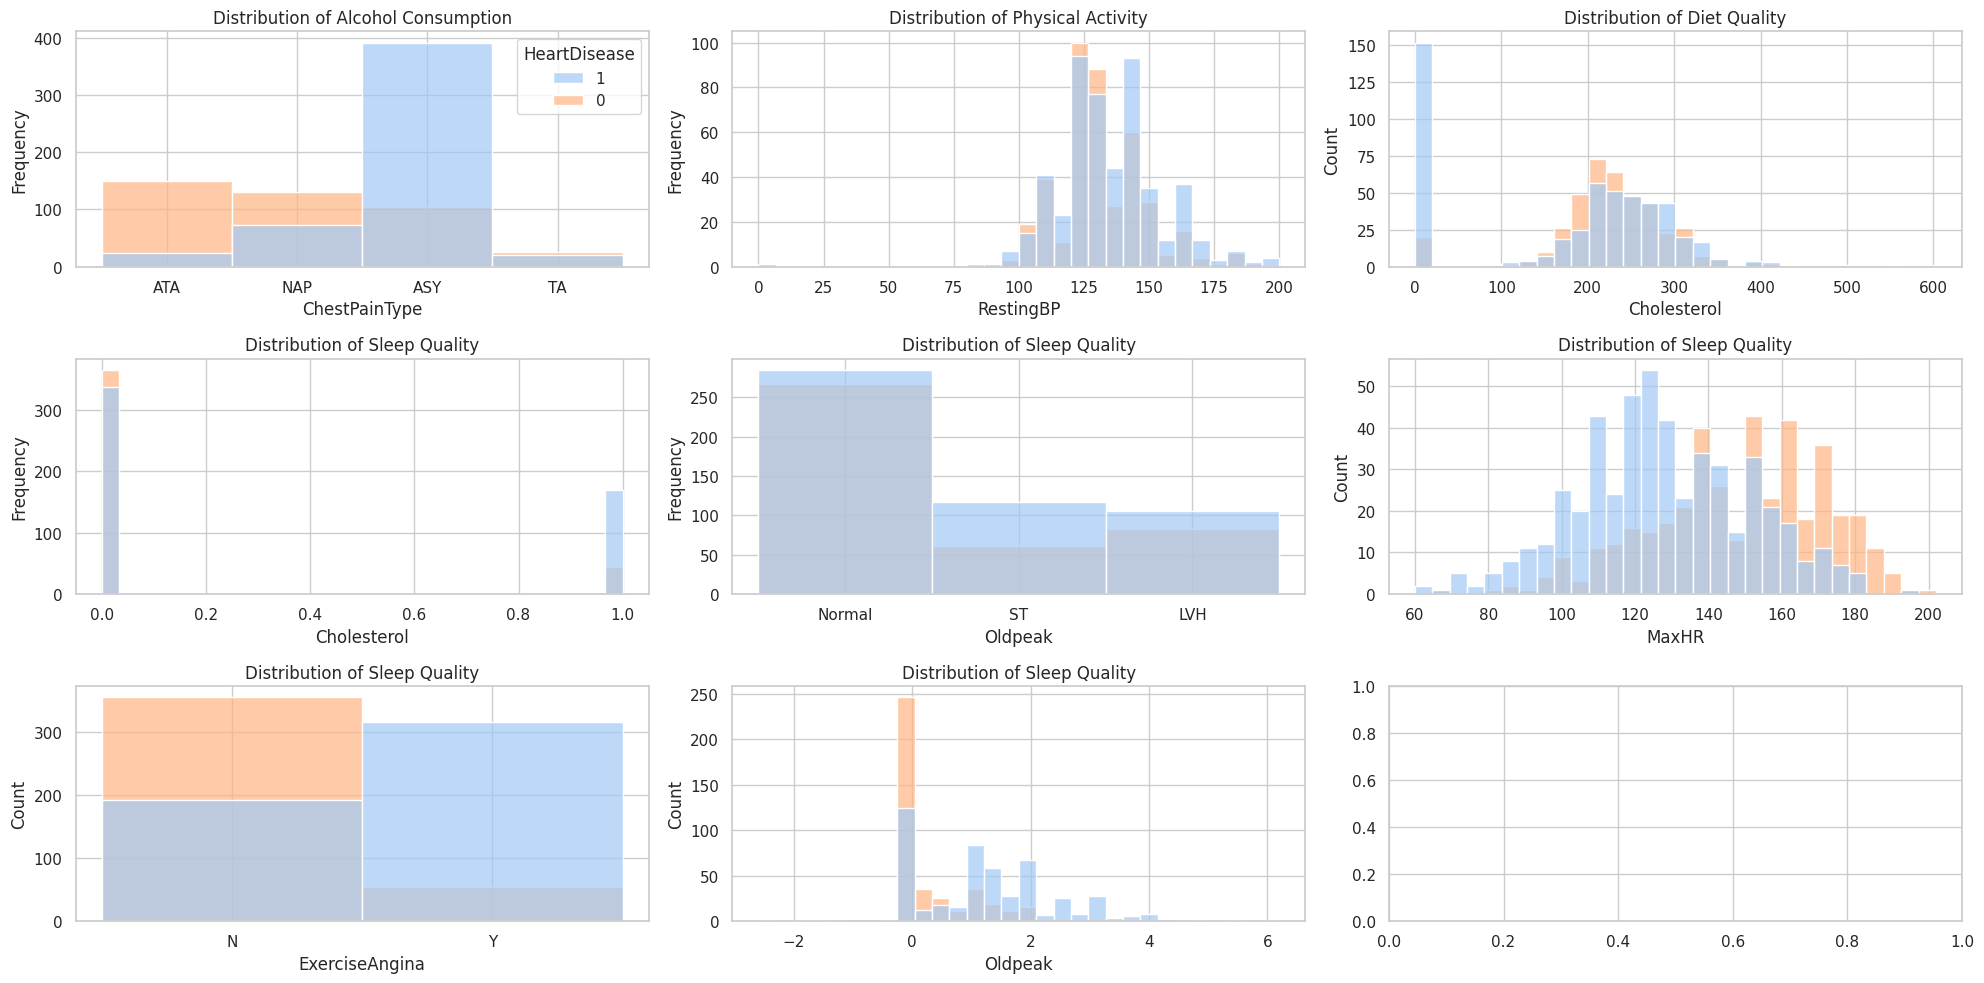

In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)

fig, axes = plt.subplots(3, 3, figsize=(20, 10))

hue_order = [1, 0]  # Adjust the order here

# Plotting each histogram with additional features
sns.histplot(ax=axes[0, 0], x='ChestPainType', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', alpha=.7).set(title='Distribution of Alcohol Consumption')
axes[0, 0].set_xlabel('ChestPainType')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(ax=axes[0, 1], x='RestingBP', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', legend=False, alpha=.7).set(title='Distribution of Physical Activity')
axes[0, 1].set_xlabel('RestingBP')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(ax=axes[0, 2], x='Cholesterol', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', legend=False, alpha=.7).set(title='Distribution of Diet Quality')
axes[1, 0].set_xlabel('Cholesterol')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(ax=axes[1, 0], x='FastingBS', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', legend=False, alpha=.7).set(title='Distribution of Sleep Quality')
axes[1, 1].set_xlabel('FastingBS')
axes[1, 1].set_ylabel('Frequency')

sns.histplot(ax=axes[1, 1], x='RestingECG', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', legend=False, alpha=.7).set(title='Distribution of Sleep Quality')
axes[1, 1].set_xlabel('RestingECG')
axes[1, 1].set_ylabel('Frequency')

sns.histplot(ax=axes[1, 2], x='MaxHR', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', legend=False, alpha=.7).set(title='Distribution of Sleep Quality')
axes[1, 1].set_xlabel('MaxHR')
axes[1, 1].set_ylabel('Frequency')

sns.histplot(ax=axes[2, 0], x='ExerciseAngina', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', legend=False, alpha=.7).set(title='Distribution of Sleep Quality')
axes[1, 1].set_xlabel('ExerciseAngina')
axes[1, 1].set_ylabel('Frequency')

sns.histplot(ax=axes[2, 1], x='Oldpeak', data=df, hue='HeartDisease', hue_order=hue_order, bins=30, palette='pastel', legend=False, alpha=.7).set(title='Distribution of Sleep Quality')
axes[1, 1].set_xlabel('Oldpeak')
axes[1, 1].set_ylabel('Frequency')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [ ]:
df["ChestPainType"].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


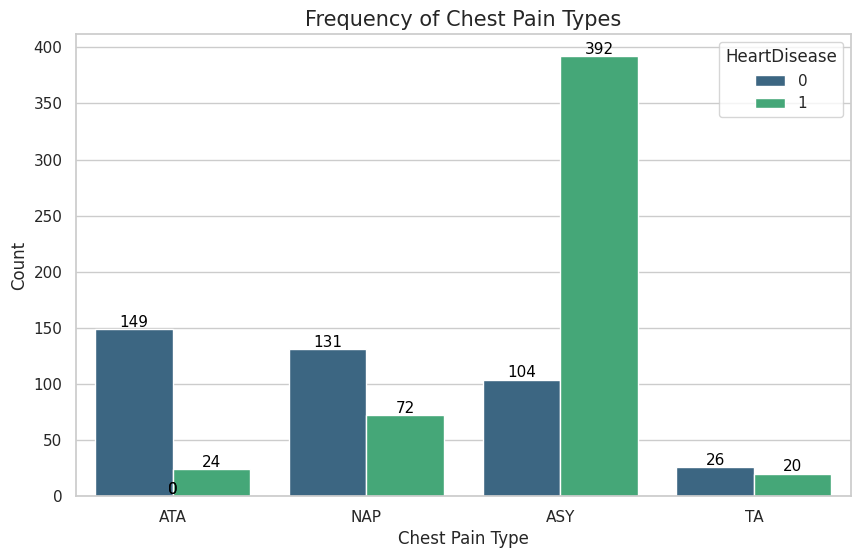

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the count plot
ax = sns.countplot(data=df, x='ChestPainType',  hue = 'HeartDisease', palette='viridis')

# Add titles and labels
plt.title('Frequency of Chest Pain Types', fontsize=15)
plt.xlabel('Chest Pain Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Optional: Add the specific counts on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [ ]:
df["Sex"].value_counts()

,count
Sex,
M,725
F,193


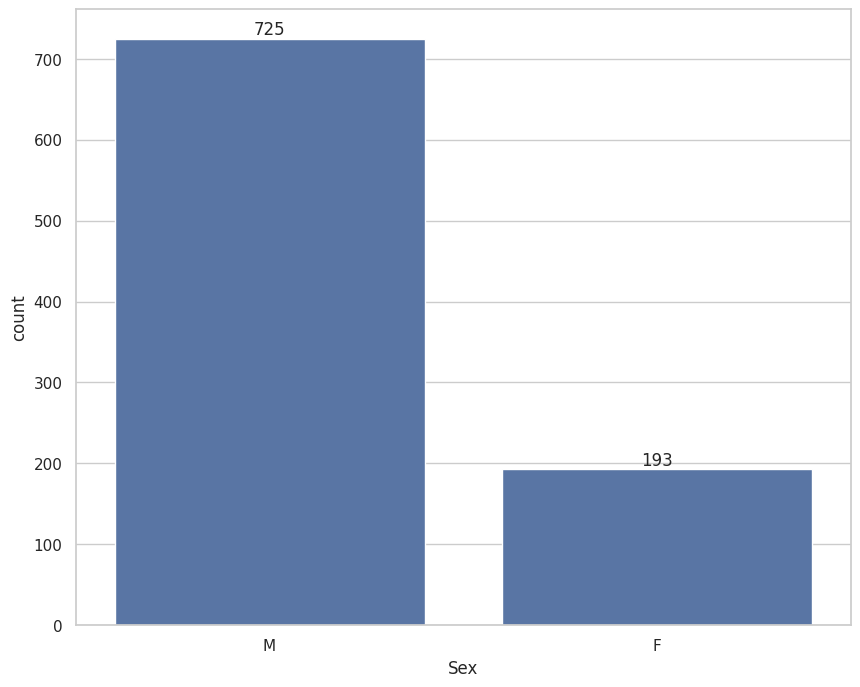

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(data = df, x = 'Sex')

for bars in ax.containers:
    ax.bar_label(bars)

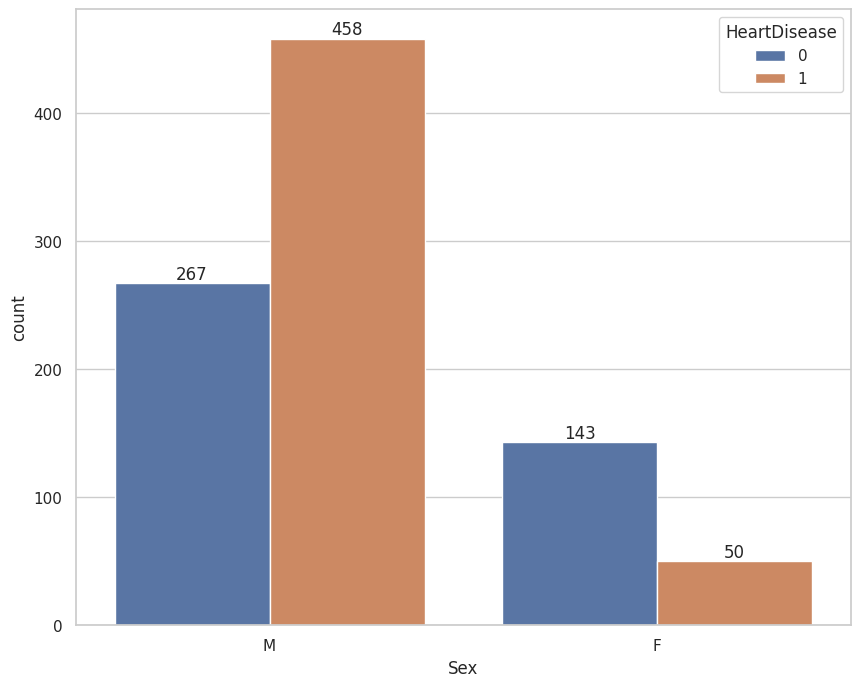

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(data = df, x = 'Sex', hue = 'HeartDisease')

for bars in ax.containers:
    ax.bar_label(bars)

# Encode the obj to numaric

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

#  Initialize the LabelEncoder
le = LabelEncoder()

# 3. List of columns to encode
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# 4. Apply Label Encoding to each column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])



In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [ ]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,0.781046,132.396514,198.799564,0.233115,0.989107,136.809368,0.404139,0.887364,1.361656,0.553377
std,9.432617,0.407701,0.956519,18.514154,109.384145,0.423046,0.631671,25.460334,0.490992,1.066570,0.607056,0.497414
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,173.250000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,138.000000,0.000000,0.600000,1.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


In [ ]:
df.corr()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
Age,1.000000,0.055750,-0.077150,0.254399,-0.095282,0.198039,-0.007484,-0.382045,0.215793,0.258612,-0.268264,0.282039
Sex,0.055750,1.000000,-0.126559,0.005133,-0.200092,0.120076,0.071552,-0.189186,0.190664,0.105734,-0.150693,0.305445
ChestPainType,-0.077150,-0.126559,1.000000,-0.020647,0.067880,-0.073151,-0.072537,0.289123,-0.354727,-0.177377,0.213521,-0.386828
RestingBP,0.254399,0.005133,-0.020647,1.000000,0.100893,0.070193,0.022656,-0.112135,0.155101,0.164803,-0.075162,0.107589
Cholesterol,-0.095282,-0.200092,0.067880,0.100893,1.000000,-0.260974,-0.196544,0.235792,-0.034166,0.050148,0.111471,-0.232741
FastingBS,0.198039,0.120076,-0.073151,0.070193,-0.260974,1.000000,0.087050,-0.131438,0.060451,0.052698,-0.175774,0.267291
RestingECG,-0.007484,0.071552,-0.072537,0.022656,-0.196544,0.087050,1.000000,-0.179276,0.077500,-0.020438,-0.006778,0.057384
MaxHR,-0.382045,-0.189186,0.289123,-0.112135,0.235792,-0.131438,-0.179276,1.000000,-0.370425,-0.160691,0.343419,-0.400421
ExerciseAngina,0.215793,0.190664,-0.354727,0.155101,-0.034166,0.060451,0.077500,-0.370425,1.000000,0.408752,-0.428706,0.494282
Oldpeak,0.258612,0.105734,-0.177377,0.164803,0.050148,0.052698,-0.020438,-0.160691,0.408752,1.000000,-0.501921,0.403951


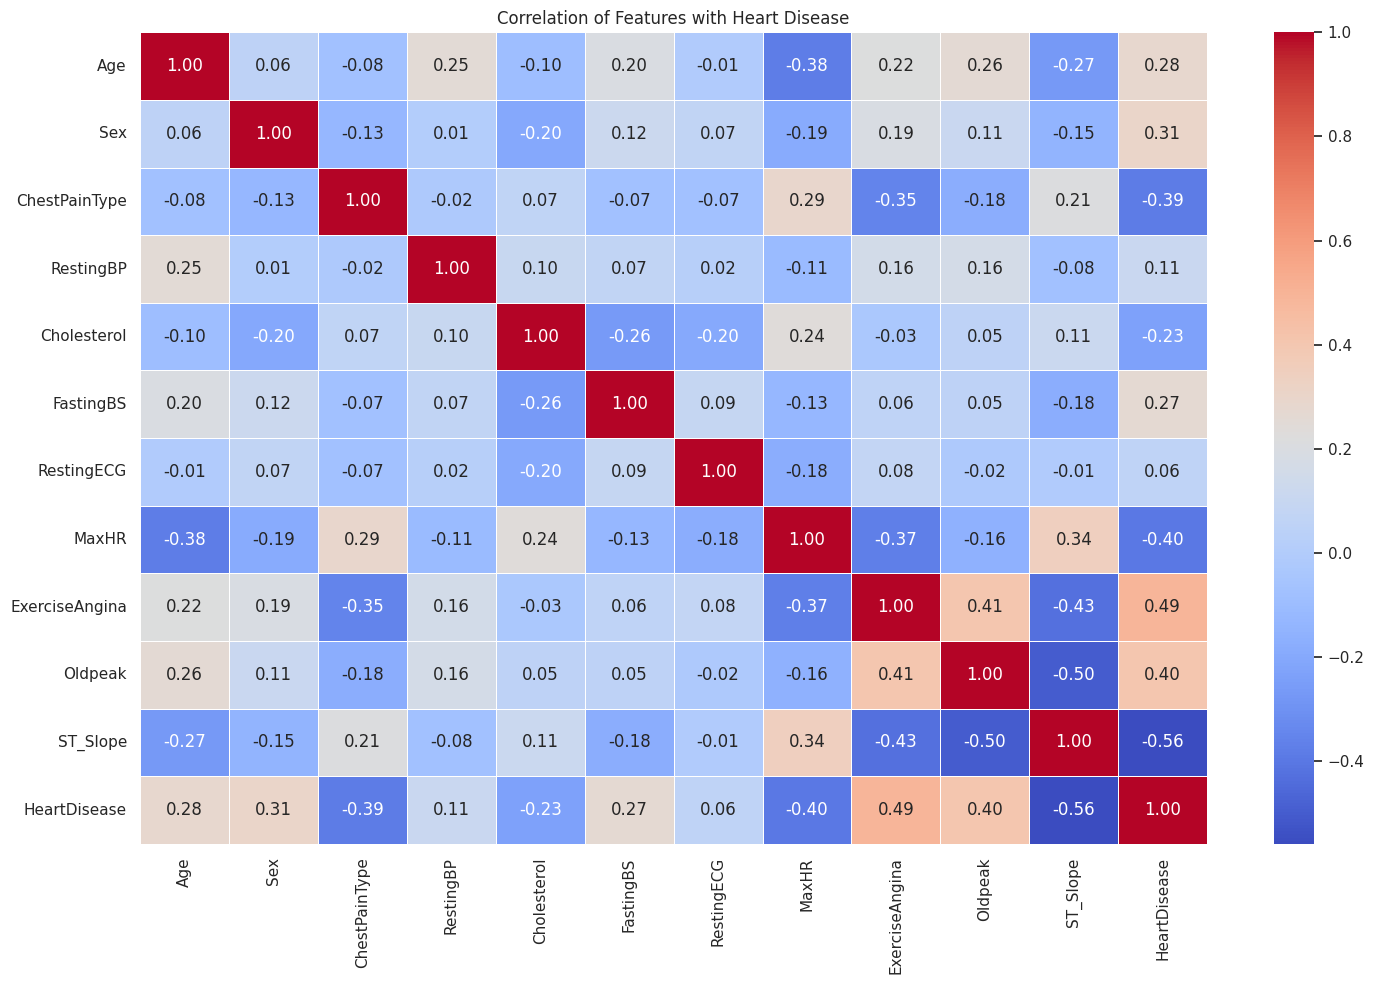

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('Correlation of Features with Heart Disease')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()

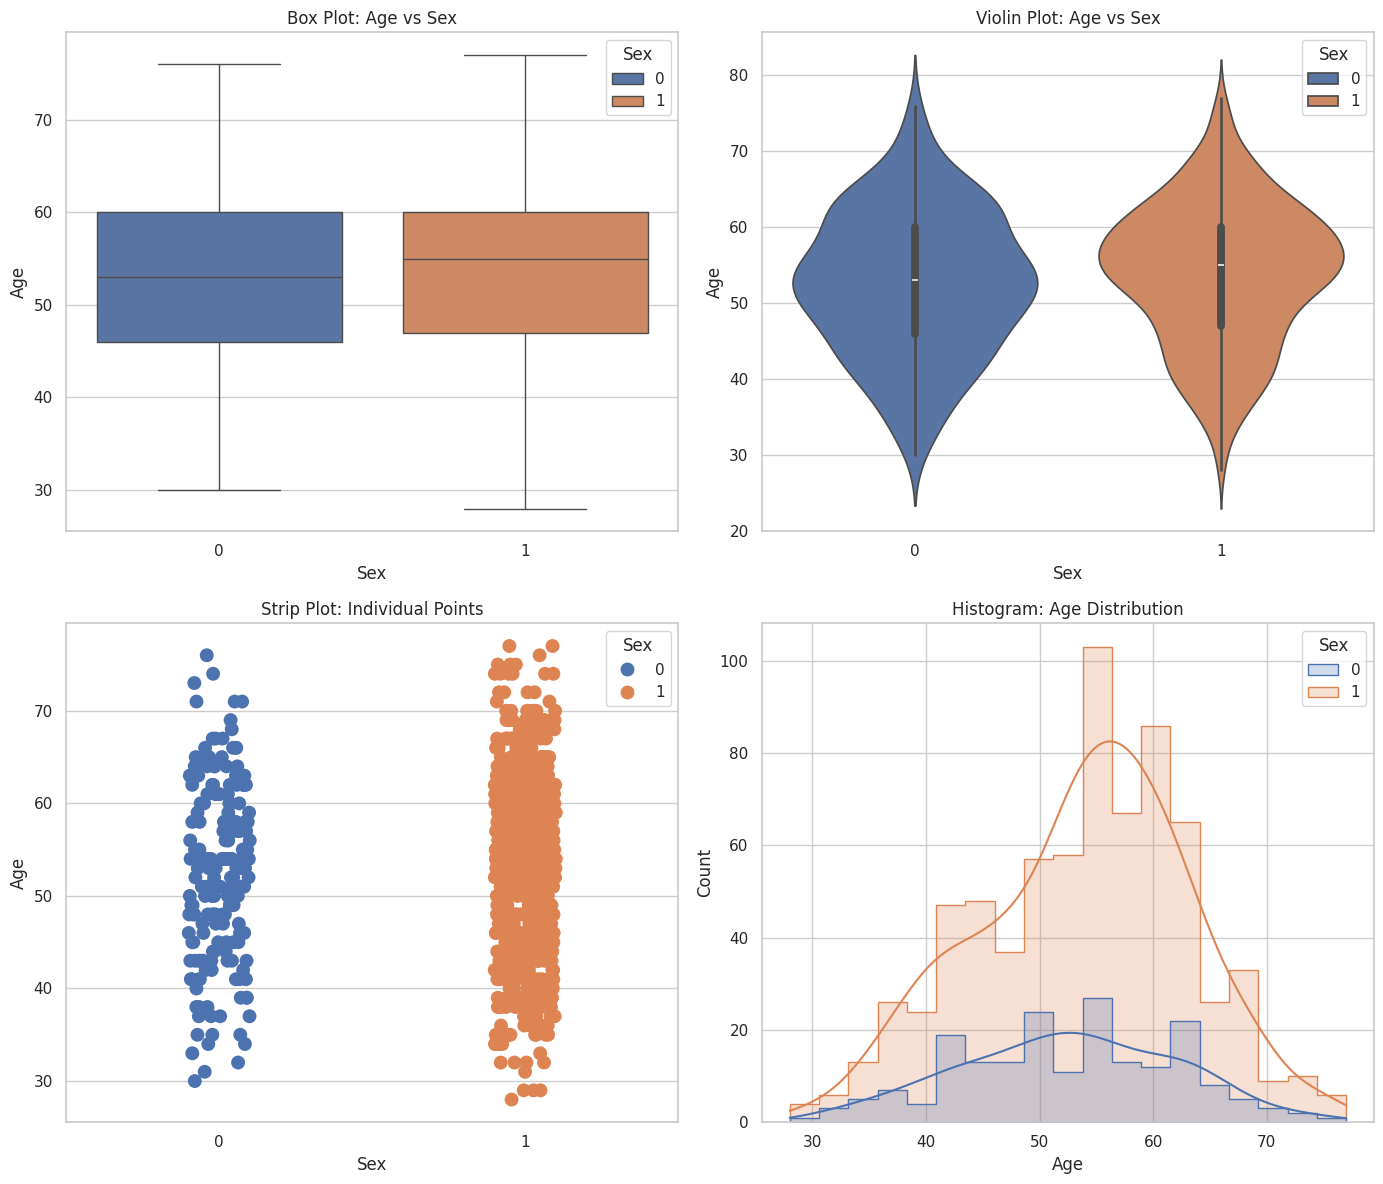

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the layout (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 2. Add specific plots to each 'ax'
sns.boxplot(data=df, x='Sex', y='Age', ax=axes[0, 0], hue='Sex')
sns.violinplot(data=df, x='Sex', y='Age', ax=axes[0, 1], hue='Sex')
sns.stripplot(data=df, x='Sex', y='Age', ax=axes[1, 0], hue='Sex', size=10)
sns.histplot(data=df, x='Age', hue='Sex', kde=True, ax=axes[1, 1], element='step')

# 3. Add titles and clean up
axes[0,0].set_title('Box Plot: Age vs Sex')
axes[0,1].set_title('Violin Plot: Age vs Sex')
axes[1,0].set_title('Strip Plot: Individual Points')
axes[1,1].set_title('Histogram: Age Distribution')

plt.tight_layout()
plt.show()

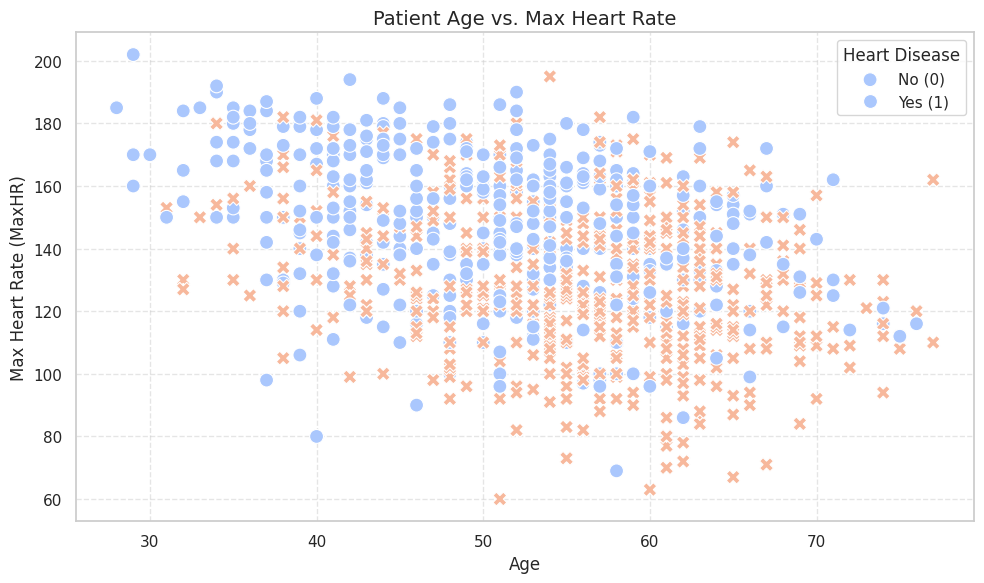

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Increase figure size for clarity
plt.figure(figsize=(10, 6))

# 2. Create scatter plot
# FIX: Changed y='HeartDisease' to y='MaxHR' to match the title
sns.scatterplot(
    data=df,
    x='Age',
    y='MaxHR',             # Continuous variable for the Y-axis
    hue='HeartDisease',    # Colors the dots by target (0 or 1)
    style='HeartDisease',  # Gives different shapes to the dots
    s=100,                 # Size of the dots
    palette='coolwarm'     # Blue for 0, Red for 1
)

# 3. Add descriptive labels and formatting
plt.title('Patient Age vs. Max Heart Rate', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Max Heart Rate (MaxHR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Improve legend readability
plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

In [ ]:
df.shape


(918, 12)

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [ ]:
X=df.drop(columns=['HeartDisease'])
y=df['HeartDisease']

In [ ]:
print(X.shape)
print(y.shape)

(918, 11)
(918,)


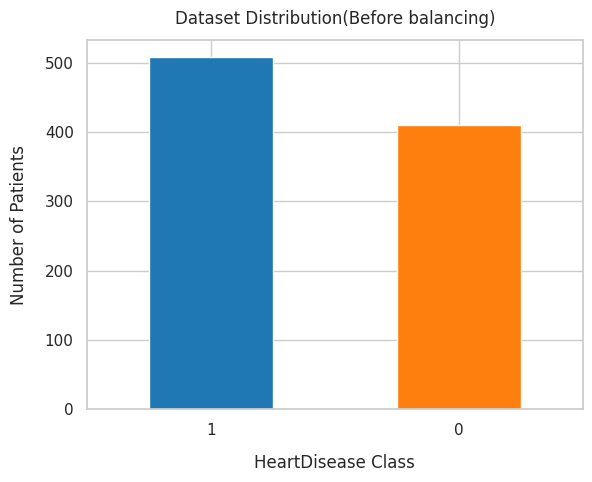

In [ ]:
colors = ['#1f77b4', '#ff7f0e']
df.HeartDisease.value_counts().plot.bar(color=colors)
plt.ylabel("Number of Patients", labelpad=12)
plt.xlabel("HeartDisease Class", labelpad=12)
plt.xticks(rotation = 0)
plt.yticks()
plt.title("Dataset Distribution(Before balancing)", y=1.02);
plt.show()

# Apply SMOTE to balance the dataset

**Synthetic Minority Oversampling Technique**

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# class distribution of  target variable 1D NumPy array





In [ ]:
np.unique(y_resampled, return_counts=True)[1]

array([508, 508])

# Convert the resampled data back to a DataFrame

In [ ]:

bdataset = pd.DataFrame(X_resampled, columns=[f"Feature_{i+1}" for i in range(X.shape[1])])
bdataset["Label"] = y_resampled

In [ ]:
bdataset.shape

(1016, 12)

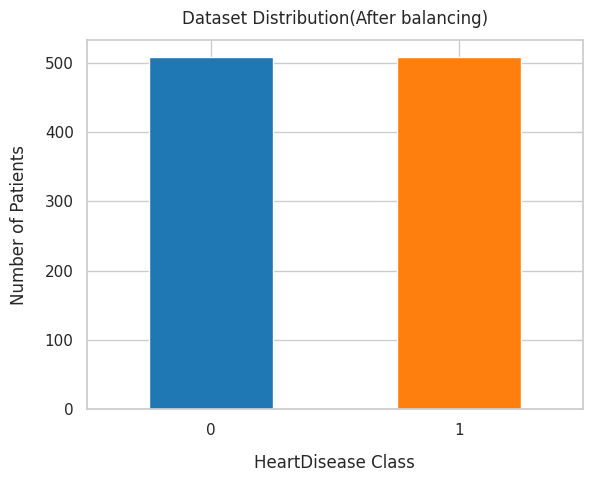

In [ ]:
# Define the colors for each bar
colors = ['#1f77b4', '#ff7f0e']
bdataset.Label.value_counts().plot.bar(color=colors)
plt.ylabel("Number of Patients", labelpad=12)
plt.xlabel("HeartDisease Class", labelpad=12)
plt.xticks(rotation = 0)
plt.title("Dataset Distribution(After balancing)", y=1.02);
plt.show()

## Applying ML model

In [ ]:
from sklearn.model_selection import train_test_split
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state= 42)

In [ ]:
print(X_Train.shape, X_Test.shape)
print(Y_Train.shape, Y_Test.shape)

(812, 11) (204, 11)
(812,) (204,)


# Knn

In [ ]:
k_model = KNeighborsClassifier()
k_model.fit(X_Train, Y_Train)

KNeighborsClassifier()

In [ ]:
predictions = k_model.predict(X_Test)

In [ ]:
cm = confusion_matrix(Y_Test, predictions)
print(cm)

[[64 24]
 [36 80]]


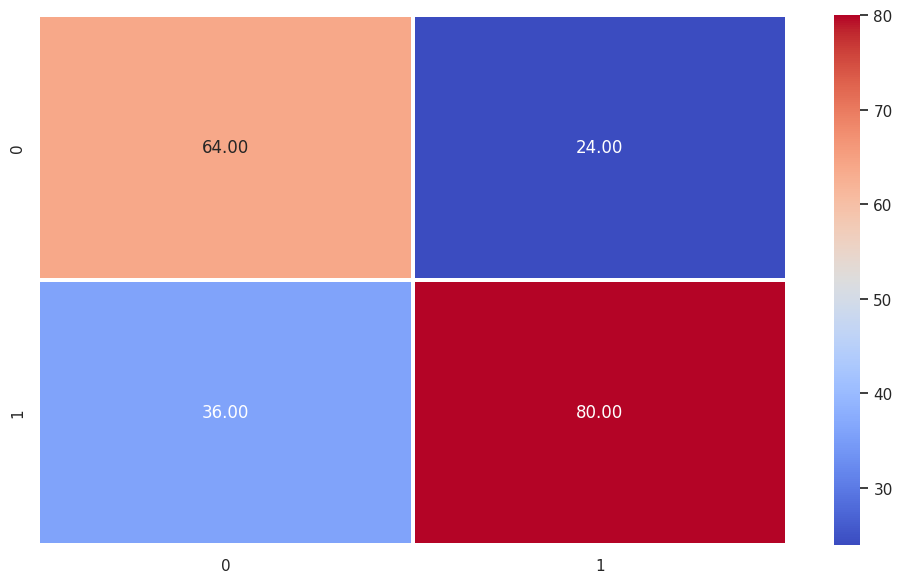

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm , annot=True, cmap='coolwarm', fmt=".2f", linewidths=1.5)
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(Y_Test, predictions))

              precision    recall  f1-score   support

           0       0.64      0.73      0.68        88
           1       0.77      0.69      0.73       116

    accuracy                           0.71       204
   macro avg       0.70      0.71      0.70       204
weighted avg       0.71      0.71      0.71       204



In [ ]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy_knn = accuracy_score(Y_Test, predictions)
precision_knn = precision_score(Y_Test, predictions, average='macro')
recall_knn = recall_score(Y_Test, predictions, average='macro')
f1_knn = f1_score(Y_Test, predictions, average='macro')


# Print the evaluation metrics
print("Accuracy: %.4f" %(accuracy_knn*100))
print("Precision: %.4f" %(precision_knn*100))
print("Recall: %.4f" %(recall_knn*100))
print("F1-score: %.4f" %(f1_knn*100))

Accuracy: 70.5882
Precision: 70.4615
Recall: 70.8464
F1-score: 70.4062


In [ ]:
print(k_model.score(X_Train, Y_Train))
print(k_model.score(X_Test, Y_Test))

0.7943349753694581
0.7058823529411765


# ROC AUC curve

Accuracy:  70.5882%
Precision: 70.4615%
Recall:    70.8464%
F1-score:  70.4062%


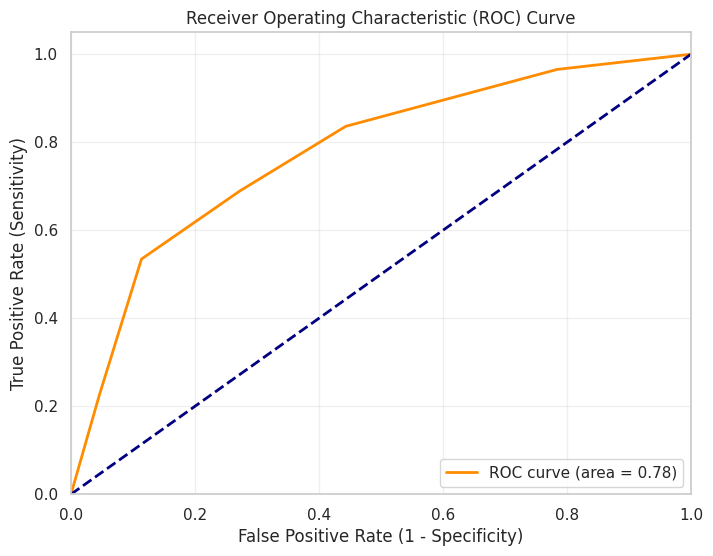

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Generate predictions and probabilities
# Assuming 'k_model' is your trained KNN or classifier
predictions = k_model.predict(X_Test)
y_probs = k_model.predict_proba(X_Test)[:, 1]

# Convert Y_Test and predictions to integer type for sklearn functions
Y_Test_int = Y_Test.astype(int)
predictions_int = predictions.astype(int)

# 2. Calculate evaluation metrics
accuracy_knn = accuracy_score(Y_Test_int, predictions_int)
precision_knn = precision_score(Y_Test_int, predictions_int, average='macro')
recall_knn = recall_score(Y_Test_int, predictions_int, average='macro')
f1_knn = f1_score(Y_Test_int, predictions_int, average='macro')

# 3. Print the evaluation metrics formatted as percentages
print(f"Accuracy:  {accuracy_knn*100:.4f}%")
print(f"Precision: {precision_knn*100:.4f}%")
print(f"Recall:    {recall_knn*100:.4f}%")
print(f"F1-score:  {f1_knn*100:.4f}%")

# 4. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_Test_int, y_probs)
roc_auc = auc(fpr, tpr)

# 5. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# SVM

In [ ]:
svm_model = SVC(probability=True)
svm_model.fit(X_Train, Y_Train)

SVC(probability=True)

In [ ]:
predictions = svm_model.predict(X_Test)

In [ ]:
cm = confusion_matrix(Y_Test, predictions)
print(cm)

[[65 23]
 [44 72]]


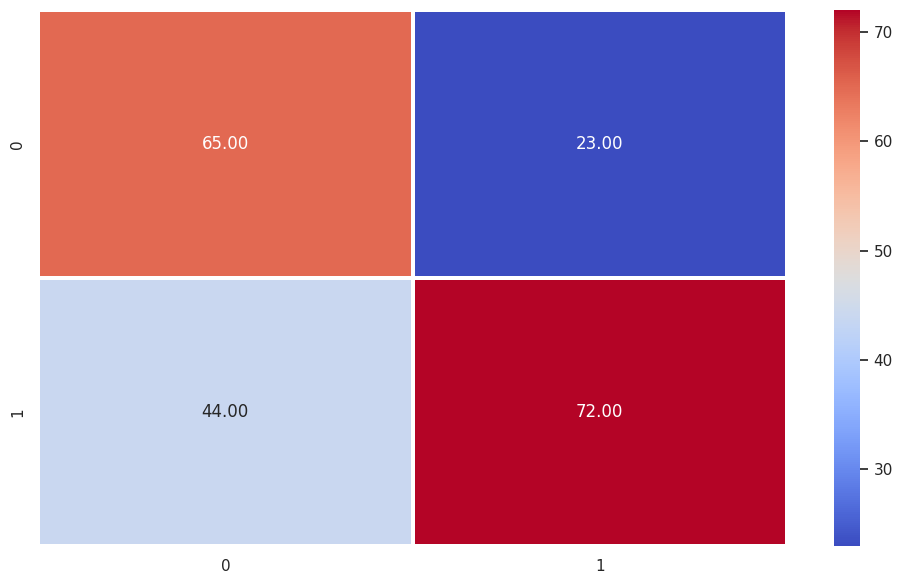

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm , annot=True, cmap='coolwarm', fmt=".2f", linewidths=1.5)
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(Y_Test, predictions))

              precision    recall  f1-score   support

           0       0.60      0.74      0.66        88
           1       0.76      0.62      0.68       116

    accuracy                           0.67       204
   macro avg       0.68      0.68      0.67       204
weighted avg       0.69      0.67      0.67       204



In [ ]:
print(svm_model.score(X_Train, Y_Train))
print(svm_model.score(X_Test, Y_Test))

0.7179802955665024
0.6715686274509803


Accuracy:  67.1569%
Precision: 67.7113%
Recall:    67.9663%
F1-score:  67.1181%


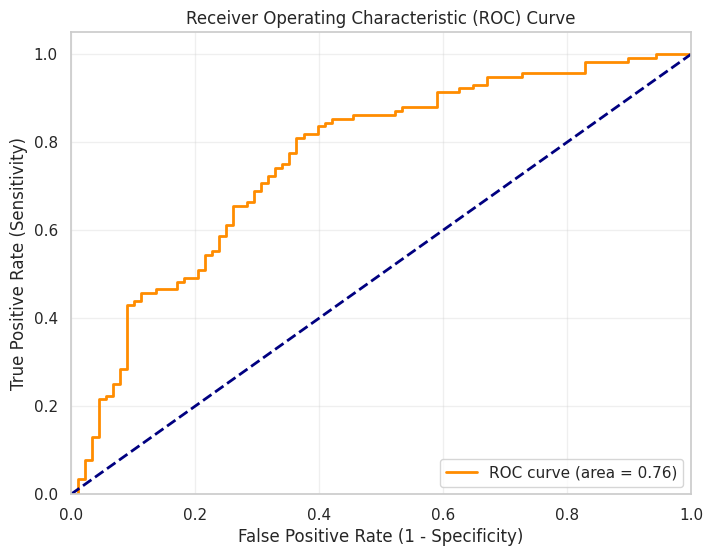

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Generate predictions and probabilities
# Assuming 'svm_model' is your trained KNN or classifier
predictions = svm_model.predict(X_Test)
y_probs = svm_model.predict_proba(X_Test)[:, 1]

# Convert Y_Test and predictions to integer type for sklearn functions
Y_Test_int = Y_Test.astype(int)
predictions_int = predictions.astype(int)

# 2. Calculate evaluation metrics
accuracy_svm = accuracy_score(Y_Test_int, predictions_int)
precision_svm = precision_score(Y_Test_int, predictions_int, average='macro')
recall_svm = recall_score(Y_Test_int, predictions_int, average='macro')
f1_svm = f1_score(Y_Test_int, predictions_int, average='macro')

# 3. Print the evaluation metrics formatted as percentages
print(f"Accuracy:  {accuracy_svm*100:.4f}%")
print(f"Precision: {precision_svm*100:.4f}%")
print(f"Recall:    {recall_svm*100:.4f}%")
print(f"F1-score:  {f1_svm*100:.4f}%")

# 4. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_Test_int, y_probs)
roc_auc = auc(fpr, tpr)

# 5. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

 # Random Forest

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_Train, Y_Train)

RandomForestClassifier()

In [ ]:
predictions = rf_model.predict(X_Test)

In [ ]:
cm = confusion_matrix(Y_Test, predictions)
print(cm)

[[ 72  16]
 [ 10 106]]


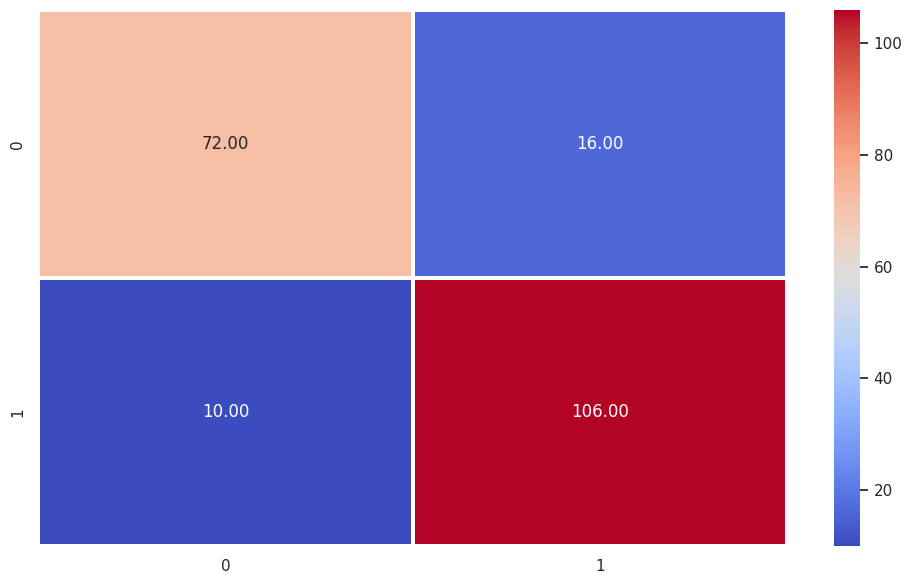

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm , annot=True, cmap='coolwarm', fmt=".2f", linewidths=1.5)
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(Y_Test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        88
           1       0.87      0.91      0.89       116

    accuracy                           0.87       204
   macro avg       0.87      0.87      0.87       204
weighted avg       0.87      0.87      0.87       204



In [ ]:
print(rf_model.score(X_Train, Y_Train))
print(rf_model.score(X_Test, Y_Test))

1.0
0.8725490196078431


Accuracy:  86.7647%
Precision: 86.4827%
Recall:    86.5792%
F1-score:  86.5287%


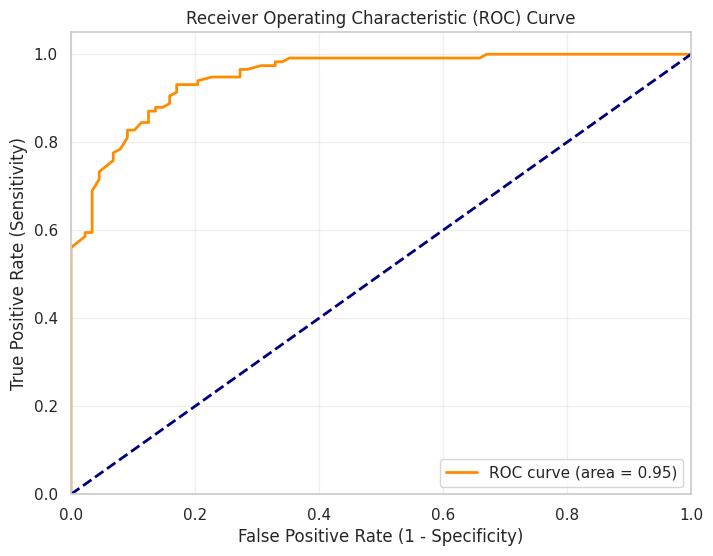

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit the RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_Train, Y_Train)

# 1. Generate predictions and probabilities
predictions = rf_model.predict(X_Test)
y_probs = rf_model.predict_proba(X_Test)[:, 1]

# Convert Y_Test and predictions to integer type for sklearn functions
Y_Test_int = Y_Test.astype(int)
predictions_int = predictions.astype(int)

# 2. Calculate evaluation metrics
accuracy_rf = accuracy_score(Y_Test_int, predictions_int)
precision_rf = precision_score(Y_Test_int, predictions_int, average='macro')
recall_rf = recall_score(Y_Test_int, predictions_int, average='macro')
f1_rf = f1_score(Y_Test_int, predictions_int, average='macro')

# 3. Print the evaluation metrics formatted as percentages
print(f"Accuracy:  {accuracy_rf*100:.4f}%")
print(f"Precision: {precision_rf*100:.4f}%")
print(f"Recall:    {recall_rf*100:.4f}%")
print(f"F1-score:  {f1_rf*100:.4f}%")

# 4. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_Test_int, y_probs)
roc_auc = auc(fpr, tpr)

# 5. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# DecisionTree

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_Train, Y_Train)

DecisionTreeClassifier()

In [ ]:
predictions = dt_model.predict(X_Test)

In [ ]:
cm = confusion_matrix(Y_Test, predictions)
print(cm)


[[ 66  22]
 [ 13 103]]


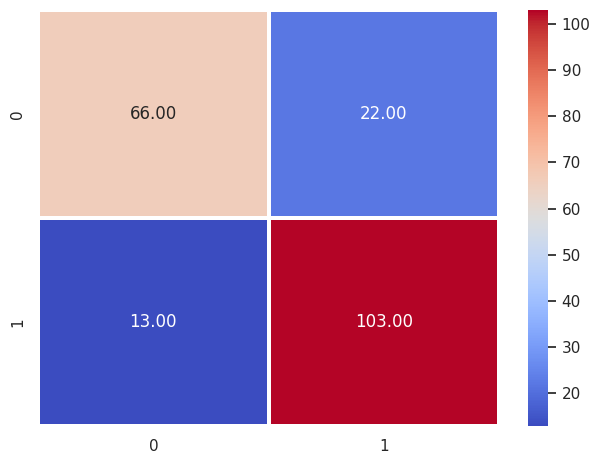

In [ ]:
sns.heatmap(cm , annot=True, cmap='coolwarm', fmt=".2f", linewidths=1.5)
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(Y_Test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.75      0.79        88
           1       0.82      0.89      0.85       116

    accuracy                           0.83       204
   macro avg       0.83      0.82      0.82       204
weighted avg       0.83      0.83      0.83       204



In [ ]:
print(dt_model.score(X_Train, Y_Train))
print(dt_model.score(X_Test, Y_Test))

1.0
0.8284313725490197


Accuracy:  82.8431%
Precision: 82.9722%
Recall:    81.8966%
F1-score:  82.2595%


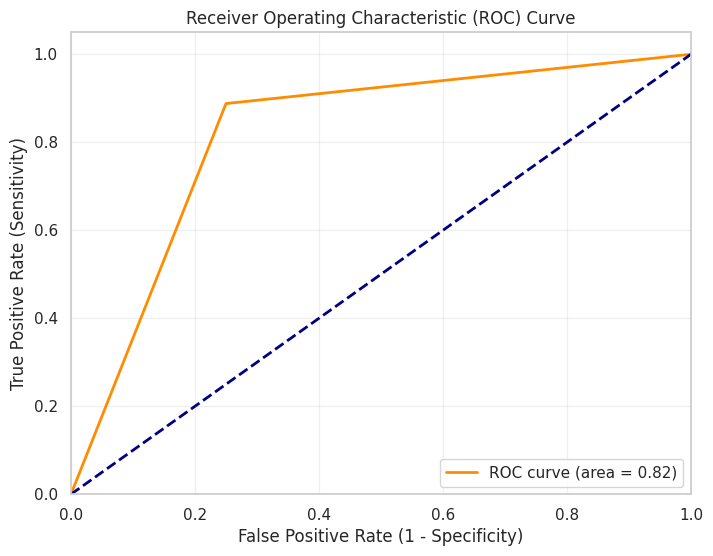

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


# 1. Generate predictions and probabilities
predictions = dt_model.predict(X_Test)
y_probs = dt_model.predict_proba(X_Test)[:, 1]

# Convert Y_Test and predictions to integer type for sklearn functions
Y_Test_int = Y_Test.astype(int)
predictions_int = predictions.astype(int)

# 2. Calculate evaluation metrics
accuracy_dt = accuracy_score(Y_Test_int, predictions_int)
precision_dt = precision_score(Y_Test_int, predictions_int, average='macro')
recall_dt = recall_score(Y_Test_int, predictions_int, average='macro')
f1_dt = f1_score(Y_Test_int, predictions_int, average='macro')

# 3. Print the evaluation metrics formatted as percentages
print(f"Accuracy:  {accuracy_dt*100:.4f}%")
print(f"Precision: {precision_dt*100:.4f}%")
print(f"Recall:    {recall_dt*100:.4f}%")
print(f"F1-score:  {f1_dt*100:.4f}%")

# 4. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_Test_int, y_probs)
roc_auc = auc(fpr, tpr)

# 5. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Logistic Regression

In [ ]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_Train, Y_Train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
predictions = lr_model.predict(X_Test)

In [ ]:
cm = confusion_matrix(Y_Test, predictions)
print(cm)

[[ 71  17]
 [ 16 100]]


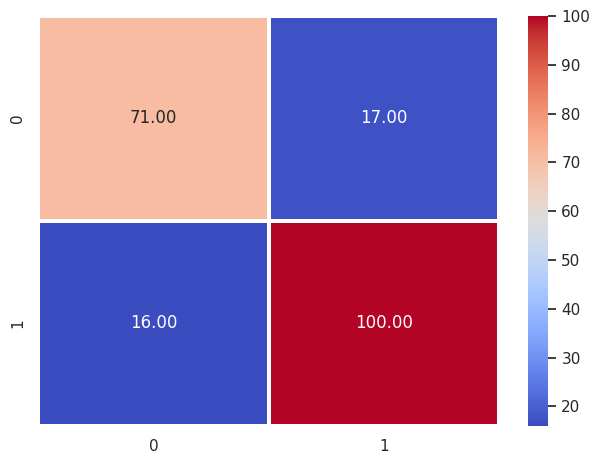

In [ ]:
sns.heatmap(cm , annot=True, cmap='coolwarm', fmt=".2f", linewidths=1.5)
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(Y_Test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81        88
           1       0.85      0.86      0.86       116

    accuracy                           0.84       204
   macro avg       0.84      0.83      0.83       204
weighted avg       0.84      0.84      0.84       204



In [ ]:
print(lr_model.score(X_Train, Y_Train))
print(lr_model.score(X_Test, Y_Test))

0.8583743842364532
0.8382352941176471


Accuracy:  83.8235%
Precision: 83.5396%
Recall:    83.4444%
F1-score:  83.4899%


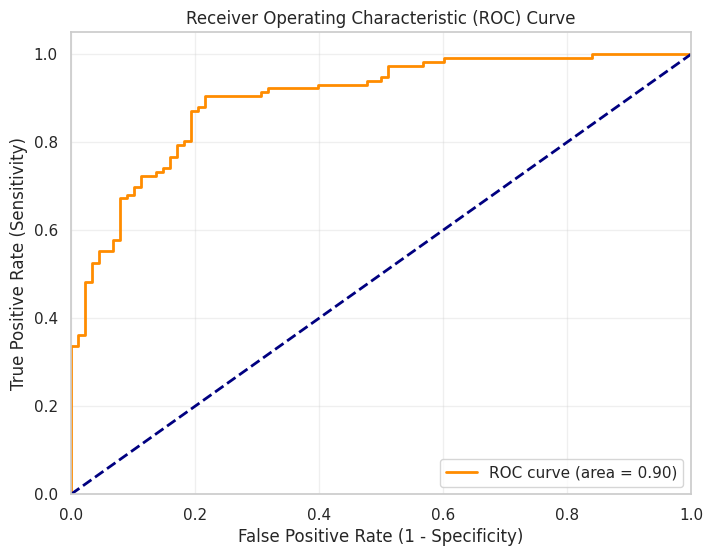

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


# 1. Generate predictions and probabilities
predictions = lr_model.predict(X_Test)
y_probs = lr_model.predict_proba(X_Test)[:, 1]

# Convert Y_Test and predictions to integer type for sklearn functions
Y_Test_int = Y_Test.astype(int)
predictions_int = predictions.astype(int)

# 2. Calculate evaluation metrics
accuracy_lr = accuracy_score(Y_Test_int, predictions_int)
precision_lr = precision_score(Y_Test_int, predictions_int, average='macro')
recall_lr = recall_score(Y_Test_int, predictions_int, average='macro')
f1_lr = f1_score(Y_Test_int, predictions_int, average='macro')

# 3. Print the evaluation metrics formatted as percentages
print(f"Accuracy:  {accuracy_lr*100:.4f}%")
print(f"Precision: {precision_lr*100:.4f}%")
print(f"Recall:    {recall_lr*100:.4f}%")
print(f"F1-score:  {f1_lr*100:.4f}%")

# 4. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(Y_Test_int, y_probs)
roc_auc = auc(fpr, tpr)

# 5. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

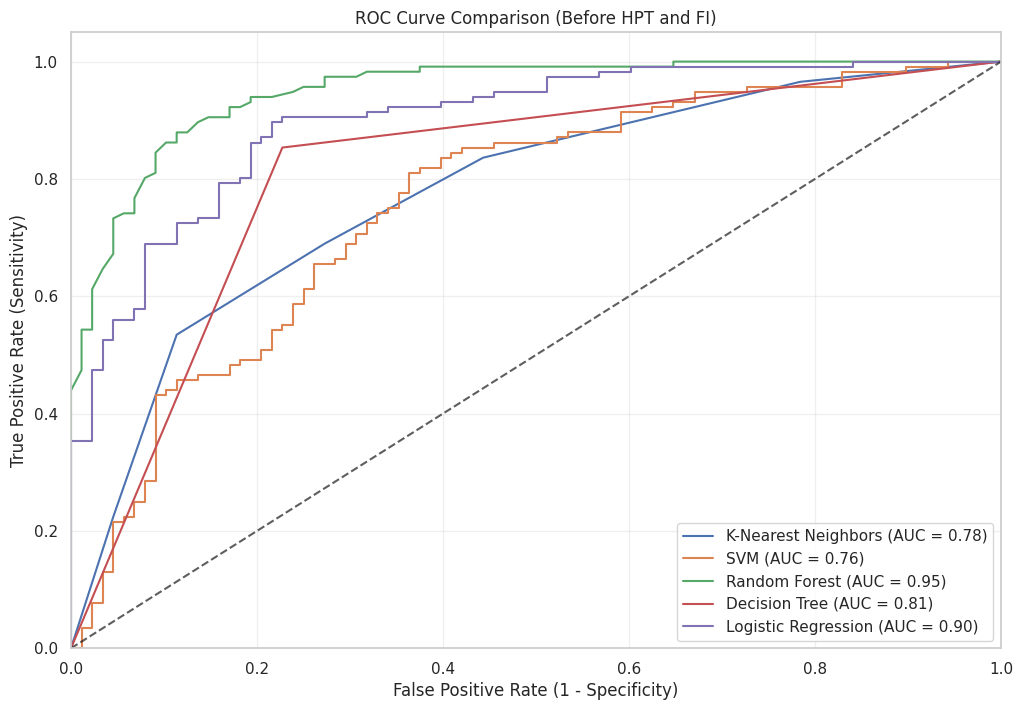

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Initialize classifiers
# Note: Added max_iter to Logistic Regression to ensure convergence on complex data
classifiers = {
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# Plot ROC curve
plt.figure(figsize=(12, 8))

for name, clf in classifiers.items():
    # Fit classifier
    clf.fit(X_Train, Y_Train)

    # Predict probabilities
    y_prob = clf.predict_proba(X_Test)[:, 1]

    # Convert Y_Test to integer type for sklearn functions
    Y_Test_int = Y_Test.astype(int)

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(Y_Test_int, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison (Before HPT and FI)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Create a random forest Classifier
fi_rf_model = RandomForestClassifier(random_state=30)
# Train a random forest model
fi_rf_model.fit(X_Train, Y_Train)

# Get feature importances
feature_importances = fi_rf_model.feature_importances_

# Create a DataFrame to display feature importances
importance_df = pd.DataFrame({'Feature': X_Train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print(importance_df)

           Feature  Importance
10        ST_Slope    0.210429
9          Oldpeak    0.133731
4      Cholesterol    0.106588
7            MaxHR    0.102887
2    ChestPainType    0.102062
8   ExerciseAngina    0.092686
0              Age    0.081562
3        RestingBP    0.075955
1              Sex    0.043309
5        FastingBS    0.025687
6       RestingECG    0.025104


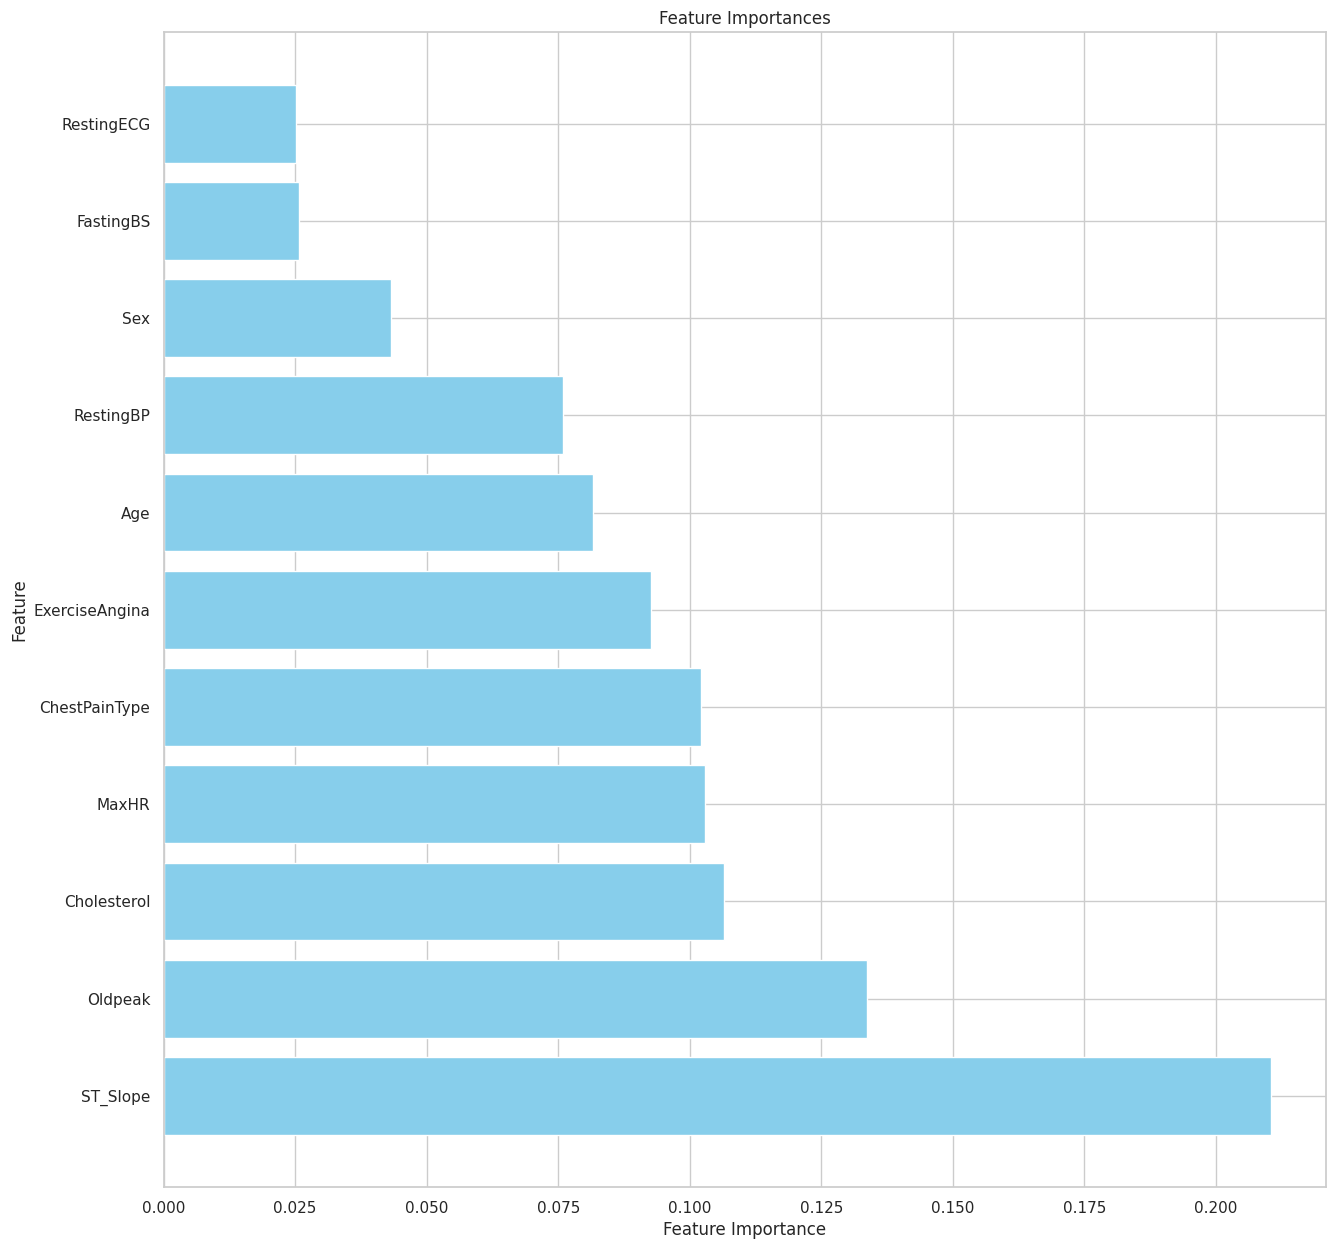

In [ ]:
plt.rcParams.update({'font.size': 20, 'font.weight': 'normal'})
plt.figure(figsize=(15, 15))
# Extract feature importances and their corresponding names
importances = fi_rf_model.feature_importances_
features = X_Train.columns

# Sort features by their importance
sorted_indices = importances.argsort()[::-1]
sorted_importances = importances[sorted_indices]
sorted_features = [features[i] for i in sorted_indices]

# Plot the feature importances
#plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), sorted_importances, align='center', color='skyblue')
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')

#download
plt.savefig('Feature Importances.png', bbox_inches='tight', facecolor='white', transparent=False)

plt.show()